# Mineria de datos
## Regresiones

### Introducción:
*En el presente trabajo se aborda un problema de minería de datos y modelización predictiva aplicado al análisis electoral en España, utilizando información a nivel municipal. El conjunto de datos empleado contiene variables de carácter demográfico, socioeconómico y electoral, junto con distintos indicadores que resumen los resultados obtenidos en las últimas elecciones.*

*El objetivo general de la práctica es analizar y modelizar el comportamiento electoral de los municipios españoles, identificando relaciones entre las variables explicativas disponibles y determinados resultados electorales. Para ello, se plantea la construcción de dos modelos de regresión distintos, cada uno adaptado a la naturaleza de la variable objetivo considerada.*

*De entre las variables objetivo disponibles en el conjunto de datos, se selecciona:*

- *Una variable objetivo continua, que permitirá estudiar cómo influyen las características de los municipios en la magnitud de un determinado resultado electoral mediante un modelo de regresión lineal.*

- *Una variable objetivo binaria, que permitirá analizar la probabilidad de que se produzca un determinado fenómeno electoral mediante un modelo de regresión logística.*

#### *a) Depuración de datos*
- *Importación de las librerias necesarias y funciones.*

In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [11]:
# Import custom functions
from FuncionesMineria import (graficoVcramer, mosaico_targetbinaria, boxplot_targetbinaria, 
                           hist_targetbinaria, Transf_Auto, lm, Rsq, validacion_cruzada_lm,
                           modelEffectSizes, crear_data_modelo, Vcramer, hist_target_categorica)

- *Para importar los datos se utiliza el siguiente código.*

In [12]:
# Import data
df_mineriaR = pd.read_excel('DatosEleccionesEspaña.xlsx')
df_mineriaR.head(10).T

,0,1,2,3,4,5,6,7,8,9
Name,Abadía,Abertura,Acebo,Acehúche,Aceituna,Ahigal,Alagón del Río,Albalá,Alcántara,Alcollarín
CodigoProvincia,10,10,10,10,10,10,10,10,10,10
CCAA,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura
TotalCensus,282,364,569,704,540,1263,826,629,1320,266
AbstentionPtge,20.213,25.275,27.241,30.114,30.185,22.565,30.024,27.027,22.803,24.436
AbstencionAlta,0,0,0,1,1,0,1,0,0,0
Izda_Pct,60.444,54.779,44.203,50.813,44.562,53.068,59.343,37.037,46.81,37.811
Dcha_Pct,35.555,44.118,53.14,45.325,49.867,45.501,37.89,60.567,50.736,58.209
Otros_Pct,1.778,0.368,0.966,0.0,0.796,0.409,0.692,0.218,0.785,0.498
Izquierda,1,1,0,1,0,1,1,0,0,0


- *Para observar la composición de los datos alojados en el dataframe "df_mineriaR", se utiliza el método .indfo(). A partir del mismo, se observa que el mismo esta compuesto por 25 variables con nombres y tipos diferentes. Al ejecutar el código se observa que las variables, CodigoProvincia, CCAA, Izquierda, Derecha, AbstencionAlta, ActividadPpal, Densidad, no han sido asignadas correctamente, tal y como se muestra a continuación.*

In [13]:
# Explore data
df_mineriaR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8117 entries, 0 to 8116
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          8117 non-null   object 
 1   CodigoProvincia               8117 non-null   int64  
 2   CCAA                          8117 non-null   object 
 3   TotalCensus                   8117 non-null   int64  
 4   AbstentionPtge                8117 non-null   float64
 5   AbstencionAlta                8117 non-null   int64  
 6   Izda_Pct                      8117 non-null   float64
 7   Dcha_Pct                      8117 non-null   float64
 8   Otros_Pct                     8117 non-null   float64
 9   Izquierda                     8117 non-null   int64  
 10  Derecha                       8117 non-null   int64  
 11  WomanPopulationPtge           8117 non-null   float64
 12  ForeignersPtge                8117 non-null   float64
 13  Sam

- *Estas variables en algunos casos son categóricas y en otras buleanas, por lo que se cambia su asignación con el siguiente código:* 

In [14]:
# change variables types
nuericaAcategorica = ['CodigoProvincia']
objetoAcategorica = ['CCAA', 'ActividadPpal', 'Densidad']
objetoAbuleano = ['Izquierda', 'Derecha', 'AbstencionAlta']

for col in nuericaAcategorica:
    df_mineriaR[col] = df_mineriaR[col].astype('category')
for col in objetoAcategorica:
    df_mineriaR[col] = df_mineriaR[col].astype('string')
for col in objetoAbuleano:
    df_mineriaR[col] = df_mineriaR[col].astype('bool')

- *A continuación, se muestra un análisis descriptivo de las variables explicativas, donde se destaca observar que:*
    - *TotalCensus: presenta una distribución altamente asimétrica a la derecha, con un coeficiente de asimetría muy elevado y una curtosis extremadamente alta. Esto indica la presencia de municipios con tamaños poblacionales muy superiores al resto, lo que es coherente con la estructura territorial española, donde conviven pequeños municipios rurales con grandes ciudades. No obstante, el amplio rango observado sugiere la necesidad de analizar esta variable en profundidad en la fase de detección de valores atípicos.*
    - *Otros_Pct: presenta una diferencia muy marcada entre la media y la mediana, junto con valores elevados de asimetría y curtosis, lo que indica que aunque en la mayoría de los municipios el porcentaje de voto a otros partidos es reducido, existen algunos casos con valores extremadamente altos que influyen de forma notable.*
    - *ForeignersPtge y SameComAutonDiffProvPtge: presenta asimetría posotiva y curtosis elevada, indicando que hay presencia de municipios con mas extranjeros que otros propia de una distribución con mas dispersión. Adicnalmente para el caso de ForeignersPtge su valor mínimo presenta negativos, lo que no puede ser conceptualmente*
    - *SameComAutonPtge: presenta asimetría negativa y curtosis positiva, aunque muy leve en ambos casos, se observan valores máximos que no corresponde a los valores normales que puede tomar esta variables, no pudiendo así superar el 100% de la muestra total.*
    - *Superfice: Muestra una mediana reducida y una asimetría positiva muy elevada, junto con una curtosis extremadamente alta. Este comportamiento refleja una fuerte heterogeneidad territorial y sugiere la presencia de valores atípicos.*
    - *Explotaciones: Presenta asimetría y curtoris extrema, con un valor máximo muy elejado de los valores típicos, se presume errores o datos perdidos.*

In [15]:
# Descriptive statistics
numericas_vars = df_mineriaR.select_dtypes(include=['int64', 'float64']).columns.tolist()
descriptivos_num = df_mineriaR[numericas_vars].describe().T
for num in numericas_vars:
    descriptivos_num.loc[num, "Asimetria"] = df_mineriaR[num].skew()
    descriptivos_num.loc[num, "Kurtosis"] = df_mineriaR[num].kurtosis()
    descriptivos_num.loc[num, "Rango"] = np.ptp(df_mineriaR[num].dropna().values)

descriptivos_num

,count,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango
TotalCensus,8117.0,4247.863989,34423.439346,5.0000,140.0000,447.000,1843.0000,2363829.000,46.544648,2893.452945,2.363824e+06
AbstentionPtge,8117.0,26.501647,7.533438,0.0000,21.6780,26.424,31.4710,57.576,-0.053736,0.493671,5.757600e+01
Izda_Pct,8117.0,34.403957,16.484308,0.0000,21.8910,35.165,46.0320,94.117,0.059882,-0.493538,9.411700e+01
Dcha_Pct,8117.0,48.912166,19.946471,0.0000,38.6900,51.579,62.1870,100.000,-0.467616,-0.175615,1.000000e+02
Otros_Pct,8117.0,14.669311,25.095942,0.0000,0.7590,1.883,16.5680,100.000,1.801338,1.851374,1.000000e+02
WomanPopulationPtge,8117.0,47.302297,4.362347,11.7650,45.7250,48.485,50.0000,72.683,-1.671102,5.800629,6.091800e+01
ForeignersPtge,8117.0,5.618322,7.348700,-8.9600,1.0600,3.590,8.1800,71.470,2.498262,11.356789,8.043000e+01
SameComAutonPtge,8117.0,81.633460,12.287323,0.0000,75.8060,84.493,90.4620,127.156,-1.522758,3.479538,1.271560e+02
SameComAutonDiffProvPtge,8117.0,4.337637,6.394942,0.0000,0.6760,2.190,5.2770,67.308,3.286828,14.560136,6.730800e+01
UnemployLess25_Ptge,8117.0,7.320241,9.408801,0.0000,0.0000,5.882,10.4670,100.000,4.150962,31.664819,1.000000e+02


- *En correspondencia también se analizan los descriptivos de las variales categóricas, sobre todo en sus frecuencias y unicidad:*
    - *Name: esta variable es meramente identificativa y no contiene información predictiva, ademas de presentar altisima cantidad de categorías.*
    - *CodigoProvincia: presenta muchas categorias (50) que probablemente tengan poco representatividad, la cual adicionalmente puede ser en gran parte recogida por CCAA.*
    - *CCAA: 17 categorías, distribución desigual pero con frecuencias elevadas en todas las categorías.*
    - *AbstencionAlta, Izquierda, Derehca: variables dicotomicas potenciales de ser elegidas como objetivo, se excluyen en función de la que se opte.*
    - *ActividadPpal: Fuerte desequilibrio entre categorías, potencial reagrupamiento de categorías.*
    - *Densidad: Fuerte desequilibrio entre categorías, potencial reagrupamiento de categorías.*

In [16]:
# Descriptive statistics for categorical variables
categoricas_vars = df_mineriaR.select_dtypes(include=['object', 'category', 'bool', 'string'])
categoricas_vars.describe().T

,count,unique,top,freq
Name,8117,8100,Torrent,2
CodigoProvincia,8117,50,9,371
CCAA,8117,17,CastillaLeón,2248
AbstencionAlta,8117,2,False,5591
Izquierda,8117,2,False,6308
Derecha,8117,2,True,5041
ActividadPpal,8117,5,Otro,4932
Densidad,8117,4,MuyBaja,6416


- *Al estudio anterior de las variables categoricas, se suma el estudio de frecuencias para cada valor que toman las varibales*
    - *Del mismo se evidencia que la variable "Densidad" presenta errores, siendo uno de sus valores un signo de interrogación (?)*
    - *El resto de las variables no presentan errores.*

In [17]:
# Frequency tables for categorical variables
frecuencias_categoricas_vars = {
    col: df_mineriaR[col].value_counts(dropna=False).sort_index()
    for col in categoricas_vars.columns
}
frecuencias_categoricas_vars["CodigoProvincia"] # replace "Densidad" with any categorical variable name to see its frequency table

CodigoProvincia
1      51
2      87
3     141
4     102
5     248
6     165
7      67
8     311
9     371
10    222
11     44
12    135
13    102
14     75
15     93
16    238
17    221
18    170
19    288
20     88
21     79
22    202
23     97
24    211
25    231
26    174
27     67
28    179
29    101
30     45
31    272
32     92
33     78
34    191
35     34
36     62
37    362
38     54
39    102
40    209
41    105
42    183
43    184
44    236
45    204
46    266
47    225
48    112
49    248
50    293
Name: count, dtype: int64

- *A partir de este momento podemos revisar la cantidad de valores nulos dentro de nuestro dataframe con veracidad a partir del siguiente código, cuyo resultado indica poca presencia de valores perdidos:*

In [18]:
# Check for missing values
df_mineriaR.isna().sum()

Name                            0
CodigoProvincia                 0
CCAA                            0
TotalCensus                     0
AbstentionPtge                  0
AbstencionAlta                  0
Izda_Pct                        0
Dcha_Pct                        0
Otros_Pct                       0
Izquierda                       0
Derecha                         0
WomanPopulationPtge             0
ForeignersPtge                  0
SameComAutonPtge                0
SameComAutonDiffProvPtge        0
UnemployLess25_Ptge             0
AgricultureUnemploymentPtge     0
IndustryUnemploymentPtge        0
ConstructionUnemploymentPtge    0
ServicesUnemploymentPtge        0
ActividadPpal                   0
SUPERFICIE                      8
Densidad                        0
PobChange_pct                   7
Explotaciones                   0
dtype: int64

- *Se presume que alguanas variables categóricas pueden ser explicadas por otras, sera el caso para CodigoProvincia con CCAA? Para ello aplicamos V de Cramer y observamos su resultado.

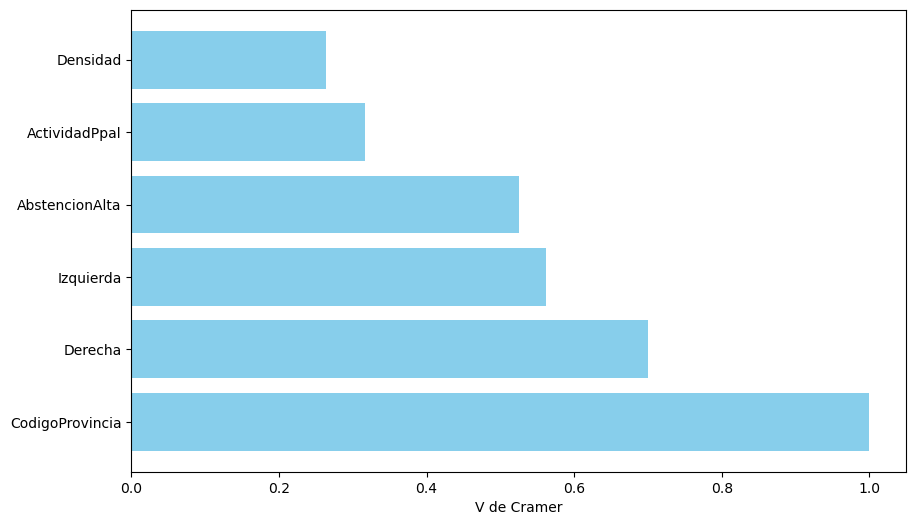

In [19]:
# Cramer's V analysis, dependence between categorical variables wwith CCAA as target
matriz = df_mineriaR[[
    "CodigoProvincia",
    "Densidad",
    "Derecha",
    "Izquierda",
    "AbstencionAlta",
    "ActividadPpal",
]]

target = df_mineriaR["CCAA"]

graficoVcramer(matriz, target)

- **Corrección de los errores detectados.**
    - *Para el caso de las variables continuas "ForeignersPtge", "SameComAutonPtge", "Explotaciones", se opta por reemplazar los valores fuera de rango o atípicos por "Nan".*
    - *En el caso de la variable categórica "Densidad", se reemplza el simbolo "?" con una nueva categoría que representa un valor desconocido.*
    - *Se quita del dataframe original la variable "Name" ya que tiene una gran cantidad de categorías con baja representación. En su mayoria se tratan de categorías únicas.*
    - *También se opta por quitar del dataframe la variable "CodigoProvincia", ya que aportaria demasiada complejidad al modelo con casi 50 categorías distintas, y gran parte de su información esta siendo recogida por la variable CCAA*

In [20]:
# Data cleaning
df_limpio = df_mineriaR.copy() # create a copy of the original dataframe to clean
df_limpio.loc[df_limpio['ForeignersPtge'] < 0, 'ForeignersPtge'] = np.nan # assign NaN to invalid percentage values
df_limpio.loc[df_limpio['SameComAutonPtge'] > 100, 'SameComAutonPtge'] = np.nan # assign NaN to invalid percentage values
df_limpio.loc[df_limpio['Explotaciones'] == 99999, 'Explotaciones'] = np.nan # assign NaN to placeholder values
df_limpio['Densidad'] = df_limpio['Densidad'].replace({'?': 'Desconocida'}) # consolidate density categories 
df_limpio = df_limpio.drop(columns=['Name', 'CodigoProvincia']) # drop unnecessary columns

In [21]:
# Save cleaned data
df_limpio.to_pickle("df_limpio.pkl")

#### **b) Construcción de los modelos de regresión**

In [22]:
# read cleaned data
df_reg = pd.read_pickle("df_limpio.pkl")

- **Regresión lineal**
  - ***Variable objetivo:** `Dcha_Pct` (porcentaje de votos a partidos de derecha).*
  - ***Justificación de la elección:***
    *`Dcha_Pct` es una variable continua, acotada entre 0 y 100, que permite analizar de forma gradual el efecto de distintas variables socio-demográficas sobre el apoyo electoral a los partidos de derecha. No requiere transformaciones para su modelización y, durante la fase de análisis exploratorio, no se observaron valores elevados de asimetría ni curtosis que sugieran desviaciones importantes respecto a una distribución aproximadamente simétrica.*

    

In [23]:
varObj = df_reg['Dcha_Pct']  # target variable
df_imputRL = df_reg.drop(columns=['Dcha_Pct'])  # predictor variables